# EDA

Purpose: inspect the raw loan default data before building the bronze, silver, and gold layers.

## 1. Environment Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pyspark
import pyspark.sql.functions as F
from pyspark.sql import Window
from pyspark.sql.types import StringType, IntegerType, FloatType, DoubleType, DateType, NumericType

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print(sys.executable)
print(Path.cwd())

c:\Users\blues\AppData\Local\Programs\Python\Python314\python.exe
c:\Personal\Work\Github\mitb-cs611-mle-assignment-2\notebooks


In [43]:
# check if the current working directory is the project root or its parent
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# define paths for data, datamart, and reports
DATA_DIR = PROJECT_ROOT / "data"
DATAMART_DIR = PROJECT_ROOT / "datamart"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

def spark_path(path):
    """Get the absolute path of a given path."""
    return Path(path).resolve().as_posix()

spark = (pyspark.sql.SparkSession.builder
         .appName("assignment_2_notebook")
         .master("local[*]")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

# print project root and Spark version
print(f"Project root: {PROJECT_ROOT}")
print(f"Spark version: {spark.version}")

Project root: /opt/airflow/project
Spark version: 3.5.1


## 2. Load Raw Sources

In [3]:
raw_files = {"loans": DATA_DIR / "lms_loan_daily.csv",
             "clickstream": DATA_DIR / "feature_clickstream.csv",
             "attributes": DATA_DIR / "features_attributes.csv",
             "financials": DATA_DIR / "features_financials.csv"}

# read raw data files into Spark DataFrames
raw = {name: spark.read.option("header", True).option("inferSchema", True).csv(spark_path(path)) for name, path in raw_files.items()}

# create a list DataFrame to summarize the raw data files
count_rows = []
for name, df in raw.items():
    count_rows.append({"source_name": name, "file_name": raw_files[name].name, "row_count": df.count(), "column_count": len(df.columns)})

inventory = pd.DataFrame(count_rows)
display(inventory)

,source_name,file_name,row_count,column_count
0,loans,lms_loan_daily.csv,137500,11
1,clickstream,feature_clickstream.csv,215376,22
2,attributes,features_attributes.csv,12500,6
3,financials,features_financials.csv,12500,22


In [4]:
# display the schema of each raw DataFrame
for name, df in raw.items():
    print(f"\n{name} schema")
    df.printSchema()


loans schema
root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: integer (nullable = true)
 |-- due_amt: double (nullable = true)
 |-- paid_amt: double (nullable = true)
 |-- overdue_amt: double (nullable = true)
 |-- balance: double (nullable = true)
 |-- snapshot_date: date (nullable = true)


clickstream schema
root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14:

In [5]:
# display the first 5 rows of each raw DataFrame
for name, df in raw.items():
    print(f"\n{name} preview")
    display(df.limit(5).toPandas())


loans preview


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,0,10000,0.0,0.0,0.0,10000.0,2023-05-01
1,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2023-06-01
2,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2023-07-01
3,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,3,10000,1000.0,0.0,1000.0,8000.0,2023-08-01
4,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,4,10000,1000.0,2000.0,0.0,6000.0,2023-09-01



clickstream preview


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,164,105,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,203,190,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,14,203,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,6,197,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,34,12,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01



attributes preview


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1000,Alistair Barrf,18,913-74-1218,Lawyer,2023-05-01
1,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
2,CUS_0x100b,Shirboni,19,#F%$D@*&8,Media_Manager,2024-03-01
3,CUS_0x1011,Schneyerh,44,793-05-8223,Doctor,2023-11-01
4,CUS_0x1013,Cameront,44,930-49-9615,Mechanic,2023-12-01



financials preview


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1000,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, and Home Equity Loan",57,26,1.63,11.0,Bad,1562.91,30.077191,10 Years and 9 Months,Yes,42.941090,77.31427572208112,High_spent_Medium_value_payments,400.36080052211616,2023-05-01
1,CUS_0x1009,52312.68_,4250.390000,6,5,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",5,18,9.73,4.0,_,202.68,40.286997,31 Years and 0 Months,Yes,108.366467,58.66019164829086,High_spent_Medium_value_payments,508.01234122645366,2025-01-01
2,CUS_0x100b,113781.38999999998,9549.782500,1,4,1,0,None,14,8,8.34,4.0,Good,1030.2,28.592943,15 Years and 10 Months,No,0.000000,617.0792665202719,High_spent_Small_value_payments,597.8989834797281,2024-03-01
3,CUS_0x1011,58918.47,5208.872500,3,3,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27,13,14.42,7.0,Standard,473.14,27.829959,15 Years and 10 Months,Yes,123.434939,383.35084463651407,Low_spent_Medium_value_payments,294.1014665671429,2023-11-01
4,CUS_0x1013,98620.98,7962.415000,3,3,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12,9,1.33,3.0,Good,1233.51,26.524864,17 Years and 10 Months,No,228.018084,332.3337079767732,High_spent_Medium_value_payments,485.8897083704929,2023-12-01


## 3. Date and Key Coverage

Objective: Check date coverage across tables.

In [6]:
# summarize the date coverage of each raw DataFrame
date_coverage_rows = []
for name, df in raw.items():
    date_col = "snapshot_date" if "snapshot_date" in df.columns else None
    if date_col:
        date_df = df.withColumn(date_col, F.to_date(date_col))
        summary = date_df.agg(F.min(date_col).alias("min_snapshot_date"), 
                              F.max(date_col).alias("max_snapshot_date"),
                              F.countDistinct(date_col).alias("snapshot_months"),
                              F.countDistinct("Customer_ID").alias("unique_customers")).toPandas().iloc[0].to_dict()
        summary["source_name"] = name
        date_coverage_rows.append(summary)

date_coverage = pd.DataFrame(date_coverage_rows)[["source_name", "min_snapshot_date", "max_snapshot_date", "snapshot_months", "unique_customers"]]
display(date_coverage)

,source_name,min_snapshot_date,max_snapshot_date,snapshot_months,unique_customers
0,loans,2023-01-01,2025-11-01,35,12500
1,clickstream,2023-01-01,2024-12-01,24,8974
2,attributes,2023-01-01,2025-01-01,25,12500
3,financials,2023-01-01,2025-01-01,25,12500


In [7]:
# summarize the number of snapshots for each raw DataFrame
snapshot_counts = []
for name, df in raw.items():
    if "snapshot_date" in df.columns:
        monthly = (df.withColumn("snapshot_date", F.to_date("snapshot_date")).groupBy("snapshot_date").agg(F.count("*").alias("row_count")).withColumn("source_name", F.lit(name)).orderBy("snapshot_date"))
        snapshot_counts.append(monthly)

snapshot_profile = snapshot_counts[0]
for other in snapshot_counts[1:]:
    snapshot_profile = snapshot_profile.unionByName(other)

display(snapshot_profile.orderBy("source_name", "snapshot_date").toPandas())

,snapshot_date,row_count,source_name
0,2023-01-01,530,attributes
1,2023-02-01,501,attributes
2,2023-03-01,506,attributes
3,2023-04-01,510,attributes
4,2023-05-01,521,attributes
5,2023-06-01,517,attributes
6,2023-07-01,471,attributes
7,2023-08-01,481,attributes
8,2023-09-01,454,attributes
9,2023-10-01,487,attributes


## 4. Missing and Placeholder Values

Objective: Check nulls or placeholder strings such as `_`, `NA`, `_______`, and occasional invalid tokens.

In [8]:
df

DataFrame[Customer_ID: string, Annual_Income: string, Monthly_Inhand_Salary: double, Num_Bank_Accounts: int, Num_Credit_Card: int, Interest_Rate: int, Num_of_Loan: string, Type_of_Loan: string, Delay_from_due_date: int, Num_of_Delayed_Payment: string, Changed_Credit_Limit: string, Num_Credit_Inquiries: double, Credit_Mix: string, Outstanding_Debt: string, Credit_Utilization_Ratio: double, Credit_History_Age: string, Payment_of_Min_Amount: string, Total_EMI_per_month: double, Amount_invested_monthly: string, Payment_Behaviour: string, Monthly_Balance: string, snapshot_date: date]

In [9]:
INVALID_STRINGS = ["", "na", "n/a", "nan", "none", "null", "_", "_______", "!@9#%8"]

def missing_summary(df):
    """Summarize missing or placeholder values in a DataFrame."""
    total = df.count()
    expressions = []
    for c in df.columns:
        normalized = F.lower(F.trim(F.col(c).cast("string")))
        expressions.append(F.sum(F.when(F.col(c).isNull() | normalized.isin(INVALID_STRINGS), 1).otherwise(0)).alias(c))
    summary = df.select(expressions).toPandas().T.reset_index()
    summary.columns = ["column_name", "missing_or_placeholder_count"]
    summary["missing_or_placeholder_rate"] = summary["missing_or_placeholder_count"] / max(total, 1)
    return summary[summary['missing_or_placeholder_count'] > 0].sort_values("missing_or_placeholder_rate", ascending=False)

# display the top missing or placeholder columns for each raw DataFrame
for name, df in raw.items():
    print(f"\nTop missing / placeholder columns: {name}")
    display(missing_summary(df))


Top missing / placeholder columns: loans


,column_name,missing_or_placeholder_count,missing_or_placeholder_rate



Top missing / placeholder columns: clickstream


,column_name,missing_or_placeholder_count,missing_or_placeholder_rate



Top missing / placeholder columns: attributes


,column_name,missing_or_placeholder_count,missing_or_placeholder_rate
4,Occupation,880,0.0704



Top missing / placeholder columns: financials


,column_name,missing_or_placeholder_count,missing_or_placeholder_rate
12,Credit_Mix,2611,0.20888
7,Type_of_Loan,1426,0.11408
19,Payment_Behaviour,998,0.07984
10,Changed_Credit_Limit,254,0.02032


## 5. Data Quality Validation Rules

Objective: Check data quality for some cases such as invalid strings, numeric casting/range checks, SSN pattern checks, and source-specific rule summaries.

In [10]:
def sample_values(df, column_name, condition, sample_limit=8):
    """Sample values from a DataFrame column based on a condition."""

    if column_name not in df.columns:
        return []
    rows = df.where(condition).select(column_name).distinct().limit(sample_limit).collect()
    return [row[column_name] for row in rows]

def invalid_string_check(df, source_name, column_name):
    """Check for invalid strings or null values in a DataFrame column."""
    
    normalized = F.lower(F.trim(F.col(column_name).cast("string")))
    condition = F.col(column_name).isNull() | normalized.isin(INVALID_STRINGS)
    count = df.where(condition).count()
    return {"source_name": source_name,
            "column_name": column_name,
            "check_type": "invalid_string_or_null",
            "violation_count": count,
            "sample_values": sample_values(df, column_name, condition)}

def invalid_numeric_check(df, source_name, column_name, min_value=None, max_value=None):
    """Check for invalid numeric values in a DataFrame column."""

    raw_text = F.trim(F.col(column_name).cast("string"))
    normalized = F.lower(raw_text)

    # Treat known placeholders as invalid/missing-like numeric values
    placeholder = F.col(column_name).isNull() | normalized.isin(INVALID_STRINGS)

    # Clean common numeric noise only, such as commas and trailing underscores
    cleaned = F.regexp_replace(raw_text, r"[,_]", "")

    # Require the cleaned value to be a proper numeric string
    valid_numeric_format = cleaned.rlike(r"^-?\d+(\.\d+)?$")

    casted = F.when(valid_numeric_format, cleaned.cast("double"))
    condition = placeholder | (raw_text.isNotNull() & (raw_text != "") & ~placeholder & ~valid_numeric_format)

    if min_value is not None:
        condition = condition | (casted < F.lit(min_value))
    if max_value is not None:
        condition = condition | (casted > F.lit(max_value))
    count = df.where(condition).count()

    return {"source_name": source_name,
            "column_name": column_name,
            "check_type": "invalid_numeric_or_out_of_range",
            "violation_count": count,
            "sample_values": sample_values(df, column_name, condition)}

def invalid_ssn_check(df, source_name, column_name="SSN"):
    """Check for invalid SSN values in a DataFrame column."""
    condition = F.col(column_name).isNull() | ~F.col(column_name).cast("string").rlike(r"^\d{3}-\d{2}-\d{4}$")
    count = df.where(condition).count()
    return {"source_name": source_name, 
            "column_name": column_name,
            "check_type": "invalid_ssn",
            "violation_count": count,
            "sample_values": sample_values(df, column_name, condition)}

def unexpected_category_check(df, source_name, column_name, valid_values):
    """Check for unexpected categorical values in a DataFrame column."""
    condition = F.col(column_name).isNotNull() & ~F.col(column_name).isin(valid_values)
    count = df.where(condition).count()
    return {"source_name": source_name,
            "column_name": column_name,
            "check_type": "unexpected_category",
            "violation_count": count,
            "sample_values": sample_values(df, column_name, condition)}

In [11]:
financial_numeric_ranges = {"Annual_Income": (0, None),
                            "Monthly_Inhand_Salary": (0, None),
                            "Num_Bank_Accounts": (0, 50),
                            "Num_Credit_Card": (0, 50),
                            "Interest_Rate": (0, 100),
                            "Num_of_Loan": (0, 50),
                            "Delay_from_due_date": (None, None),
                            "Num_of_Delayed_Payment": (0, 100),
                            "Changed_Credit_Limit": (None, None),
                            "Num_Credit_Inquiries": (0, 100),
                            "Outstanding_Debt": (0, None),
                            "Credit_Utilization_Ratio": (0, 100),
                            "Total_EMI_per_month": (0, None),
                            "Amount_invested_monthly": (0, None),
                            "Monthly_Balance": (None, None)}

loan_numeric_ranges = {"tenure": (0, None),
                       "installment_num": (0, None),
                       "loan_amt": (0, None),
                       "due_amt": (0, None),
                       "paid_amt": (0, None),
                       "overdue_amt": (0, None),
                       "balance": (0, None)}

valid_payment_behaviours = ["High_spent_Large_value_payments",
                            "High_spent_Medium_value_payments",
                            "High_spent_Small_value_payments",
                            "Low_spent_Large_value_payments",
                            "Low_spent_Medium_value_payments",
                            "Low_spent_Small_value_payments"]

checks = []
# perform data quality checks on each raw DataFrame
for source_name, df in raw.items():
    for key_col in [c for c in ["Customer_ID", "snapshot_date"] if c in df.columns]:
        checks.append(invalid_string_check(df, source_name, key_col))

# perform numeric range checks for financial and loan DataFrames
for col_name, (min_value, max_value) in financial_numeric_ranges.items():
    checks.append(invalid_numeric_check(raw["financials"], "financials", col_name, min_value, max_value))

# perform numeric range checks for loan DataFrame
for col_name, (min_value, max_value) in loan_numeric_ranges.items():
    checks.append(invalid_numeric_check(raw["loans"], "loans", col_name, min_value, max_value))

# perform numeric checks for clickstream features
for i in range(1, 21):
    checks.append(invalid_numeric_check(raw["clickstream"], "clickstream", f"fe_{i}"))

# perform specific checks for attributes DataFrame
checks.append(invalid_numeric_check(raw["attributes"], "attributes", "Age", 18, 99))
checks.append(invalid_ssn_check(raw["attributes"], "attributes"))
checks.append(unexpected_category_check(raw["financials"], "financials", "Payment_Behaviour", valid_payment_behaviours))

# create a DataFrame to summarize the violation checks
violation_detail = pd.DataFrame(checks)
violation_detail["sample_values"] = violation_detail["sample_values"].apply(lambda values: ", ".join(map(str, values)))
display(violation_detail[violation_detail["violation_count"] > 0]
        .sort_values(["source_name", "check_type", "violation_count"], ascending=[True, True, False])
        .reset_index(drop=True))

,source_name,column_name,check_type,violation_count,sample_values
0,attributes,Age,invalid_numeric_or_out_of_range,988,"5645, 3441, 5316, 1265, 3553, 581, 169, 5498"
1,attributes,SSN,invalid_ssn,703,#F%$D@*&8
2,financials,Num_of_Loan,invalid_numeric_or_out_of_range,563,"1159, 1171_, 1412, 387, 87, 966, 365, 146"
3,financials,Num_Credit_Card,invalid_numeric_or_out_of_range,289,"148, 1238, 858, 1395, 1084, 516, 883, 879"
4,financials,Interest_Rate,invalid_numeric_or_out_of_range,268,"3749, 2366, 2866, 2711, 3213, 1884, 2025, 3089"
5,financials,Changed_Credit_Limit,invalid_numeric_or_out_of_range,254,_
6,financials,Num_Credit_Inquiries,invalid_numeric_or_out_of_range,189,"1761.0, 692.0, 160.0, 1826.0, 1940.0, 1146.0, ..."
7,financials,Num_of_Delayed_Payment,invalid_numeric_or_out_of_range,187,"1473_, 853, 3858, -1, 2138, 938, 3107, 2587"
8,financials,Num_Bank_Accounts,invalid_numeric_or_out_of_range,168,"1645, 833, 1483, 858, 1650, 588, 53, 918"
9,financials,Payment_Behaviour,unexpected_category,998,!@9#%8


In [12]:
# create a summary DataFrame to aggregate the violation counts and affected columns
violation_summary = (violation_detail[violation_detail["violation_count"] > 0]
                     .groupby(["source_name", "check_type"], as_index=False)
                     .agg(affected_columns=("column_name", "nunique"), total_violations=("violation_count", "sum"))
                     .sort_values(["source_name", "total_violations"], ascending=[True, False]))
display(violation_summary)

,source_name,check_type,affected_columns,total_violations
0,attributes,invalid_numeric_or_out_of_range,1,988
1,attributes,invalid_ssn,1,703
2,financials,invalid_numeric_or_out_of_range,7,1918
3,financials,unexpected_category,1,998


In [13]:
# display the violation details for each source
for source_name in ["attributes", "financials", "clickstream", "loans"]:
    print(f"\n{source_name} violations")
    display(violation_detail[(violation_detail["source_name"] == source_name) & (violation_detail["violation_count"] > 0)].sort_values("violation_count", ascending=False))


attributes violations


,source_name,column_name,check_type,violation_count,sample_values
50,attributes,Age,invalid_numeric_or_out_of_range,988,"5645, 3441, 5316, 1265, 3553, 581, 169, 5498"
51,attributes,SSN,invalid_ssn,703,#F%$D@*&8



financials violations


,source_name,column_name,check_type,violation_count,sample_values
52,financials,Payment_Behaviour,unexpected_category,998,!@9#%8
13,financials,Num_of_Loan,invalid_numeric_or_out_of_range,563,"1159, 1171_, 1412, 387, 87, 966, 365, 146"
11,financials,Num_Credit_Card,invalid_numeric_or_out_of_range,289,"148, 1238, 858, 1395, 1084, 516, 883, 879"
12,financials,Interest_Rate,invalid_numeric_or_out_of_range,268,"3749, 2366, 2866, 2711, 3213, 1884, 2025, 3089"
16,financials,Changed_Credit_Limit,invalid_numeric_or_out_of_range,254,_
17,financials,Num_Credit_Inquiries,invalid_numeric_or_out_of_range,189,"1761.0, 692.0, 160.0, 1826.0, 1940.0, 1146.0, ..."
15,financials,Num_of_Delayed_Payment,invalid_numeric_or_out_of_range,187,"1473_, 853, 3858, -1, 2138, 938, 3107, 2587"
10,financials,Num_Bank_Accounts,invalid_numeric_or_out_of_range,168,"1645, 833, 1483, 858, 1650, 588, 53, 918"



clickstream violations


,source_name,column_name,check_type,violation_count,sample_values



loans violations


,source_name,column_name,check_type,violation_count,sample_values


## 6. Loan Behavior and Target

Objective: Check loan behaviour and target.

,snapshot_date,row_count,avg_overdue_amt,overdue_rate,dpd30_rate
0,2023-01-01,530,0.000000,0.000000,0.000000
1,2023-02-01,1031,24.248303,0.024248,0.024248
2,2023-03-01,1537,66.363045,0.059206,0.059206
3,2023-04-01,2047,123.106986,0.095261,0.095261
4,2023-05-01,2568,176.401869,0.112539,0.112539


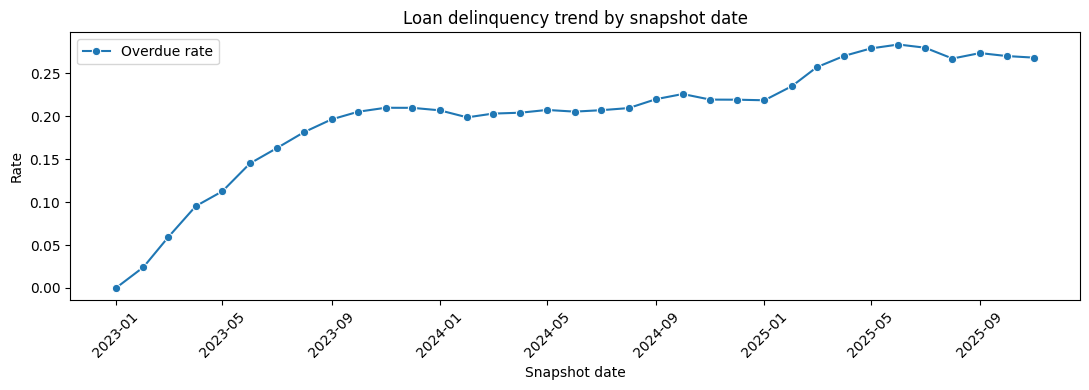

In [14]:
# analyze loan delinquency trends over time
loans = (raw["loans"].withColumn("snapshot_date", F.to_date("snapshot_date"))
                     .withColumn("due_amt", F.col("due_amt").cast("double"))
                     .withColumn("overdue_amt", F.col("overdue_amt").cast("double"))
                     .withColumn("installment_num", F.col("installment_num").cast("int"))
                     .withColumn("installments_missed", F.when(F.col("due_amt") > 0, F.ceil(F.coalesce(F.col("overdue_amt"), F.lit(0.0)) / F.col("due_amt"))).otherwise(F.lit(0)))
                     .withColumn("dpd", F.when(F.coalesce(F.col("overdue_amt"), F.lit(0.0)) > 0, F.col("installments_missed") * 30).otherwise(F.lit(0)).cast("int"))
)

# summarize loan delinquency trends by snapshot date
loan_trend = (
    loans.groupBy("snapshot_date")
    .agg(F.count("*").alias("row_count"),
         F.avg("overdue_amt").alias("avg_overdue_amt"),
         F.avg((F.col("overdue_amt") > 0).cast("double")).alias("overdue_rate"),
         F.avg((F.col("dpd") >= 30).cast("double")).alias("dpd30_rate"))
    .orderBy("snapshot_date")
    .toPandas()
)
display(loan_trend.head())

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=loan_trend, x="snapshot_date", y="overdue_rate", marker="o", label="Overdue rate", ax=ax)
ax.set_title("Loan delinquency trend by snapshot date")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Rate")
plt.xticks(rotation=45)
plt.tight_layout()

,installment_num,row_count,dpd30_rate,avg_overdue_amt
0,0,12500,0.00000,0.00
1,1,12500,0.05656,56.56
2,2,12500,0.11216,134.40
3,3,12500,0.17872,260.80
4,4,12500,0.23368,441.12
5,5,12500,0.28816,729.28
6,6,12500,0.28816,1017.44
7,7,12500,0.28816,1305.60
8,8,12500,0.28816,1593.76
9,9,12500,0.28816,1881.92


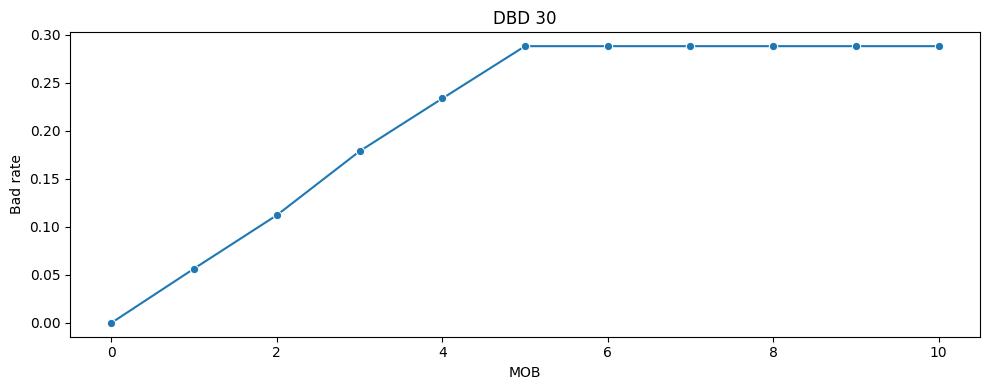

In [15]:
# analyze loan delinquency trends MOB
mob_profile = (loans.groupBy("installment_num")
               .agg(F.count("*").alias("row_count"),F.avg((F.col("dpd") >= 30).cast("double")).alias("dpd30_rate"), F.avg("overdue_amt").alias("avg_overdue_amt"))
               .orderBy("installment_num")
               .toPandas())

display(mob_profile.head(20))

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=mob_profile, x="installment_num", y="dpd30_rate", marker="o", ax=ax)
ax.set_title("DBD 30")
ax.set_xlabel("MOB")
ax.set_ylabel("Bad rate")
plt.tight_layout()

## 7. Feature Distribution

Objective: Check feature distribution.

In [16]:
financials = raw["financials"]
categorical_checks = {"Credit_Mix": financials.groupBy("Credit_Mix").count().orderBy(F.desc("count")),
                      "Payment_Behaviour": financials.groupBy("Payment_Behaviour").count().orderBy(F.desc("count")),
                      "Payment_of_Min_Amount": financials.groupBy("Payment_of_Min_Amount").count().orderBy(F.desc("count")),
                      "Occupation": raw["attributes"].groupBy("Occupation").count().orderBy(F.desc("count"))}

for name, df in categorical_checks.items():
    print(f"\n{name}")
    display(df.toPandas())


Credit_Mix


,Credit_Mix,count
0,Standard,4497
1,Good,3032
2,_,2611
3,Bad,2360



Payment_Behaviour


,Payment_Behaviour,count
0,Low_spent_Small_value_payments,3202
1,High_spent_Medium_value_payments,2242
2,Low_spent_Medium_value_payments,1686
3,High_spent_Large_value_payments,1683
4,High_spent_Small_value_payments,1389
5,Low_spent_Large_value_payments,1300
6,!@9#%8,998



Payment_of_Min_Amount


,Payment_of_Min_Amount,count
0,Yes,6571
1,No,4491
2,NM,1438



Occupation


,Occupation,count
0,_______,880
1,Lawyer,828
2,Architect,795
3,Engineer,793
4,Accountant,791
5,Scientist,789
6,Teacher,782
7,Media_Manager,780
8,Developer,780
9,Mechanic,780


In [17]:
# display numeric profile for each raw DataFrame
def numeric_profile(df, source_name):
    numeric_cols = [field.name for field in df.schema.fields if isinstance(field.dataType, NumericType)]
    if not numeric_cols:
        return pd.DataFrame()
    profile = df.select(numeric_cols).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").toPandas()
    profile.insert(0, "source_name", source_name)
    return profile

for source_name, df in raw.items():
    profile = numeric_profile(df, source_name)
    if not profile.empty:
        print(f"\nNumeric profile: {source_name}")
        display(profile)


Numeric profile: loans


,source_name,summary,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance
0,loans,count,137500,137500,137500,137500,137500,137500,137500
1,loans,mean,10.0,5.0,10000.0,909.0909090909091,711.810909090909,871.9054545454545,5871.905454545455
2,loans,stddev,0.0,3.162289159422599,0.0,287.48083267477995,485.72685937838196,2002.6725443189466,3070.777574545779
3,loans,min,10,0,10000,0.0,0.0,0.0,0.0
4,loans,25%,10,2,10000,1000.0,0.0,0.0,3000.0
5,loans,50%,10,5,10000,1000.0,1000.0,0.0,7000.0
6,loans,75%,10,8,10000,1000.0,1000.0,0.0,8000.0
7,loans,max,10,10,10000,1000.0,4000.0,10000.0,10000.0



Numeric profile: clickstream


,source_name,summary,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,clickstream,count,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376
1,clickstream,mean,101.41479552039225,103.09619456206819,104.33370941980536,105.64850308298047,106.99667558130896,103.23592229403462,107.0703374563554,110.71872446326425,114.40635446846446,117.77579674615556,99.615537478642,99.82368044721788,100.420803617859,100.02580138919842,99.60038258673204,99.86083407622019,100.12942481984993,100.12513929128593,100.341161503603,100.04625863605973
2,clickstream,stddev,99.83359392844184,99.93000203749298,100.59986549187705,100.32606477046183,100.69360665858557,100.27038751891193,100.32326515826574,100.24369781781921,100.18613852691671,100.80768608991778,100.33542808342547,100.59117511972615,100.88182648131858,101.0703707917751,101.14590617776975,100.75187641058751,101.29842811875086,102.23158668008934,102.66680374052808,103.58935787523686
3,clickstream,min,-378,-356,-399,-307,-343,-321,-368,-361,-328,-317,-375,-344,-355,-394,-351,-342,-329,-344,-401,-354
4,clickstream,25%,34,36,36,38,39,36,39,43,47,50,32,32,33,32,31,32,32,31,31,30
5,clickstream,50%,102,103,104,106,107,103,107,111,115,118,100,100,101,100,100,100,100,100,100,100
6,clickstream,75%,169,170,172,173,175,171,174,179,182,186,167,168,168,168,168,168,169,169,170,170
7,clickstream,max,541,560,583,562,570,565,537,573,577,537,613,550,530,583,597,554,516,551,560,547



Numeric profile: financials


,source_name,summary,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
0,financials,count,12500,12500,12500,12500,12500,12500,12500,12500
1,financials,mean,4188.5923027131585,16.93992,23.17272,73.21336,21.06088,26.69528,32.34926457800977,1488.3942909941488
2,financials,stddev,3180.1476109204173,114.35081529709485,132.00586642912222,468.68222710052765,14.863091419503656,184.19382871053074,5.156815304530768,8561.449910123256
3,financials,min,303.6454166666666,-1,0,1,-5,0.0,20.10076996070649,0.0
4,financials,25%,1624.7516666666668,3,4,8,10,4.0,28.06595759168476,31.496674151519752
5,financials,50%,3085.853333333333,6,5,14,18,6.0,32.41806180178782,72.86421263526391
6,financials,75%,5944.243333333333,7,7,20,28,10.0,36.62296356358048,169.5991975127609
7,financials,max,15204.633333333331,1756,1499,5789,67,2554.0,48.19982397892475,81971.0


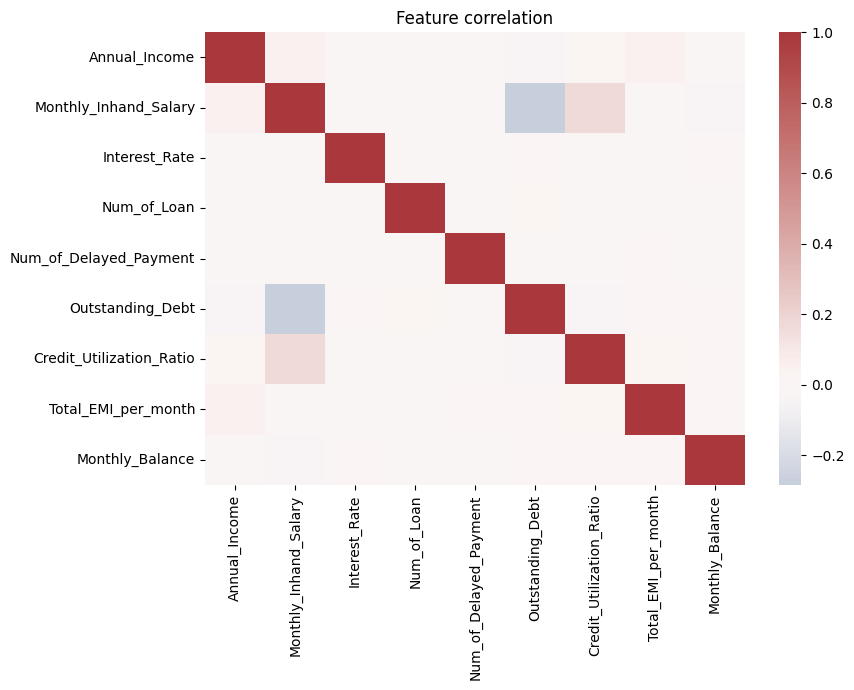

In [18]:
# analyze correlation among financial numeric features
financial_numeric_clean = raw["financials"]
for col_name in financial_numeric_ranges:
    financial_numeric_clean = financial_numeric_clean.withColumn(col_name, F.regexp_replace(F.col(col_name).cast("string"), r"[^0-9.\-]", "").cast("double"))

selected_corr_cols = ["Annual_Income",
                      "Monthly_Inhand_Salary",
                      "Interest_Rate",
                      "Num_of_Loan",
                      "Num_of_Delayed_Payment",
                      "Outstanding_Debt",
                      "Credit_Utilization_Ratio",
                      "Total_EMI_per_month",
                      "Monthly_Balance"]
available_corr_cols = [c for c in selected_corr_cols if c in financial_numeric_clean.columns]
corr_pd = financial_numeric_clean.select(available_corr_cols).sample(False, 0.25, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_pd.corr(numeric_only=True), cmap="vlag", center=0, annot=False, ax=ax)
ax.set_title("Feature correlation")
plt.tight_layout()

## 8. Cleaning and Imputation Preview

Objective: Preview values that should become null or require cleaning before imputation, including placeholder strings, invalid age values, and out-of-range clickstream features.

### Invalid placehold > null

In [19]:
def normalize_placeholder_nulls(df):
    """ Normalize placeholder values in a DataFrame by replacing them with nulls. """
    result = df
    for c in df.columns:
        normalized = F.lower(F.trim(F.col(c).cast("string")))
        result = result.withColumn(c, F.when(normalized.isin(INVALID_STRINGS), F.lit(None)).otherwise(F.col(c)))
    return result

def null_placeholder_summary(df):
    """ Summarize real nulls and placeholder strings in a DataFrame. """
    total = df.count()
    rows = []

    for c in df.columns:
        normalized = F.lower(F.trim(F.col(c).cast("string")))
        before_null_count = df.where(F.col(c).isNull()).count()

        before_placeholder_count = df.where(F.col(c).isNotNull() & normalized.isin(INVALID_STRINGS)).count()

        rows.append({"column_name": c,
                     "before_null_count": before_null_count,
                     "before_placeholder_count": before_placeholder_count,
                     "before_null_and_placeholder_count": before_null_count + before_placeholder_count,
                     "null_or_placeholder_rate": (before_null_count + before_placeholder_count) / max(total, 1)})
    return pd.DataFrame(rows).sort_values("null_or_placeholder_rate", ascending=False)


# create a preview of the data cleaning process
cleaning_preview = []
for source_name, df in raw.items():
    before = null_placeholder_summary(df)
    normalized_df = normalize_placeholder_nulls(df)
    after_exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in normalized_df.columns]

    after = normalized_df.select(after_exprs).toPandas().T.reset_index()
    after.columns = ["column_name", "after_null_count"]

    merged = before.merge(after, on="column_name", how="left")
    merged["source_name"] = source_name

    cleaning_preview.append(merged)

# combine the cleaning preview for all sources into a single DataFrame
cleaning_preview = pd.concat(cleaning_preview, ignore_index=True)

# display the cleaning preview for columns with null or placeholder values
display(cleaning_preview[cleaning_preview["before_null_and_placeholder_count"] > 0]
    [["source_name",
      "column_name",
      "before_null_count",
      "before_placeholder_count",
      "before_null_and_placeholder_count",
      "after_null_count",
      "null_or_placeholder_rate"]]
    .sort_values(["source_name", "before_null_and_placeholder_count"], ascending=[True, False]))

,source_name,column_name,before_null_count,before_placeholder_count,before_null_and_placeholder_count,after_null_count,null_or_placeholder_rate
33,attributes,Occupation,0,880,880,880,0.07040
39,financials,Credit_Mix,0,2611,2611,2611,0.20888
40,financials,Type_of_Loan,1426,0,1426,1426,0.11408
41,financials,Payment_Behaviour,0,998,998,998,0.07984
42,financials,Changed_Credit_Limit,0,254,254,254,0.02032


In [20]:
# create a preview of the imputation candidates based on the cleaning preview
imputation_candidates = (
    cleaning_preview[cleaning_preview["after_null_count"] > 0]
    .assign(suggested_handling=lambda df: np.where(df["column_name"].isin(["Customer_ID", "snapshot_date", "loan_id"]), "drop rows if key is missing", 
                                                   "impute in silver/model pipeline or keep as Unknown category"))
    [["source_name", "column_name", "after_null_count", "null_or_placeholder_rate", "suggested_handling"]]
    .sort_values(["source_name", "null_or_placeholder_rate"], ascending=[True, False])
)
display(imputation_candidates)

,source_name,column_name,after_null_count,null_or_placeholder_rate,suggested_handling
33,attributes,Occupation,880,0.07040,impute in silver/model pipeline or keep as Unk...
39,financials,Credit_Mix,2611,0.20888,impute in silver/model pipeline or keep as Unk...
40,financials,Type_of_Loan,1426,0.11408,impute in silver/model pipeline or keep as Unk...
41,financials,Payment_Behaviour,998,0.07984,impute in silver/model pipeline or keep as Unk...
42,financials,Changed_Credit_Limit,254,0.02032,impute in silver/model pipeline or keep as Unk...


### Invalid range > null

In [21]:
def out_of_range_summary(df, source_name, range_rules):
    """ Summarize out-of-range numeric values in a DataFrame based on specified range rules. """
    rows = []
    total = df.count()

    for column_name, (target_type, min_value, max_value) in range_rules.items():
        if column_name not in df.columns:
            continue

        raw_col = F.trim(F.col(column_name).cast("string"))
        cleaned_col = F.regexp_replace(raw_col, r"[^0-9.\-]", "")
        numeric_col = cleaned_col.cast(target_type)

        condition = F.lit(False)
        if min_value is not None:
            condition = condition | (numeric_col < F.lit(min_value))
        if max_value is not None:
            condition = condition | (numeric_col > F.lit(max_value))

        condition = numeric_col.isNotNull() & condition
        violation_count = df.where(condition).count()
        sample_values = (df.where(condition).select(column_name).distinct().limit(8).toPandas()[column_name].astype(str).tolist())

        rows.append({"source_name": source_name,
                     "column_name": column_name,
                     "check_type": "out_of_range_numeric",
                     "violation_count": violation_count,
                     "violation_rate": violation_count / max(total, 1),
                     "sample_values": ", ".join(sample_values)})

    return pd.DataFrame(rows)

In [22]:
range_checks = []

# Age should be between 18 and 120
age_rules = {"Age": (IntegerType(), 18, 120)}

range_checks.append(out_of_range_summary(raw["attributes"], "attributes", age_rules))

# Clickstream features should be non-negative
clickstream_rules = {f"fe_{i}": (IntegerType(), 0, None) for i in range(1, 21)}

range_checks.append(out_of_range_summary(raw["clickstream"], "clickstream", clickstream_rules))

range_check_summary = pd.concat(range_checks, ignore_index=True)

display(range_check_summary[range_check_summary["violation_count"] > 0].sort_values(["source_name", "violation_count"], ascending=[True, False]))

,source_name,column_name,check_type,violation_count,violation_rate,sample_values
0,attributes,Age,out_of_range_numeric,988,0.079040,"5645, 3441, 5316, 1265, 3553, 581, 169, 5498"
20,clickstream,fe_20,out_of_range_numeric,35829,0.166356,"-125, -35, -78, -192, -164, -265, -73, -249"
19,clickstream,fe_19,out_of_range_numeric,34918,0.162126,"-125, -35, -78, -192, -164, -73, -33, -13"
15,clickstream,fe_15,out_of_range_numeric,34778,0.161476,"-125, -35, -78, -192, -164, -73, -249, -13"
18,clickstream,fe_18,out_of_range_numeric,34733,0.161267,"-125, -35, -78, -263, -341, -192, -164, -265"
14,clickstream,fe_14,out_of_range_numeric,34541,0.160375,"-125, -35, -78, -263, -192, -164, -73, -285"
17,clickstream,fe_17,out_of_range_numeric,34460,0.159999,"-125, -35, -78, -192, -164, -73, -13, -33"
16,clickstream,fe_16,out_of_range_numeric,34318,0.159340,"-125, -35, -78, -192, -164, -73, -13, -33"
11,clickstream,fe_11,out_of_range_numeric,34235,0.158955,"-125, -35, -78, -192, -164, -73, -33, -13"
12,clickstream,fe_12,out_of_range_numeric,34194,0.158764,"-125, -35, -78, -192, -164, -73, -285, -33"


In [23]:
def replace_out_of_range_with_null(df, source_name, range_rules):
    """ Replace out-of-range numeric values with null and summarize null counts before and after cleaning. """
    result = df
    rows = []

    for column_name, (target_type, min_value, max_value) in range_rules.items():
        if column_name not in result.columns:
            continue

        raw_col = F.trim(F.col(column_name).cast("string"))
        cleaned_col = F.regexp_replace(raw_col, r"[^0-9.\-]", "")
        numeric_col = cleaned_col.cast(target_type)

        # count null before replacement
        before_null_count = result.where(F.col(column_name).isNull()).count()

        # define out-of-range condition
        out_of_range_condition = F.lit(False)
        if min_value is not None:
            out_of_range_condition = out_of_range_condition | (numeric_col < F.lit(min_value))
        if max_value is not None:
            out_of_range_condition = out_of_range_condition | (numeric_col > F.lit(max_value))
        out_of_range_condition = numeric_col.isNotNull() & out_of_range_condition

        # count how many values will be replaced with null
        replaced_with_null_count = result.where(out_of_range_condition).count()

        # replace out-of-range values with null
        result = result.withColumn(column_name, F.when(out_of_range_condition, F.lit(None)).otherwise(F.col(column_name)))

        # count null after replacement
        after_null_count = result.where(F.col(column_name).isNull()).count()

        rows.append({"source_name": source_name,
                     "column_name": column_name,
                     "before_null_count": before_null_count,
                     "replaced_with_null_count": replaced_with_null_count,
                     "after_null_count": after_null_count})

    return result, pd.DataFrame(rows)

In [24]:
# Replace invalid Age with null
attributes_cleaned, age_null_summary = replace_out_of_range_with_null(raw["attributes"], "attributes", age_rules)

# Replace negative clickstream values with null
clickstream_cleaned, clickstream_null_summary = replace_out_of_range_with_null(raw["clickstream"], "clickstream", clickstream_rules)

# Combine summary
out_of_range_null_summary = pd.concat([age_null_summary, clickstream_null_summary], ignore_index=True)

display(out_of_range_null_summary[out_of_range_null_summary["replaced_with_null_count"] > 0].sort_values(["source_name", "replaced_with_null_count"], ascending=[True, False]))

,source_name,column_name,before_null_count,replaced_with_null_count,after_null_count
0,attributes,Age,0,988,988
20,clickstream,fe_20,0,35829,35829
19,clickstream,fe_19,0,34918,34918
15,clickstream,fe_15,0,34778,34778
18,clickstream,fe_18,0,34733,34733
14,clickstream,fe_14,0,34541,34541
17,clickstream,fe_17,0,34460,34460
16,clickstream,fe_16,0,34318,34318
11,clickstream,fe_11,0,34235,34235
12,clickstream,fe_12,0,34194,34194


## 9. EDA Conclusions for the Pipeline

- Bronze should preserve the raw files as parquet without business changes.
- Silver should normalize placeholder strings, cast numeric/date fields, enforce valid SSN and age ranges, and clean categorical values.
- Gold should create the MOB-based label, align feature snapshots to future label snapshots, and add business features such as debt-to-income, EMI-to-salary, credit history months, and loan type counts.
- Model training should continue to use a time-based train/test/OOT split because snapshot month is a real temporal dimension.